In [7]:
#5.2
import numpy as np

name = input("file name: ")        #input file that you want to open
file = np.loadtxt(name, comments='#')        #open said file

x = file[:,0]        #first array x
y = file[:,1]        #second array y
y_med = np.median(y)

y2 = (y-y_med)**2

print(x)
print(y)
print(f"The minimum of x = {np.min(x)} and the maximum of x = {np.max(x)}")
print(f"The minimum of y = {np.min(y)} and the maximum of y = {np.max(y)}")
print(f"The mean of x = {np.mean(x)}")
print(f"The mean of y = {np.mean(y)}")
print(f"y2 = {y2}")

file name: bap
[2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
[0. 1. 5. 9. 9. 9. 9. 9. 9. 9.]
The minimum of x = 2.0 and the maximum of x = 2.0
The minimum of y = 0.0 and the maximum of y = 9.0
The mean of x = 2.0
The mean of y = 6.9
y2 = [81. 64. 16.  0.  0.  0.  0.  0.  0.  0.]


In [32]:
#5.6
import numpy as np

a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

#row x column
print(f" the shape of the array: {np.concatenate((a, b))} is a 1x6")       #add the two rows together (samenvoegen) 


a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6], [7, 8]])

print(f"The array {np.concatenate((a, b))} is a 4x2")
print(f"The array {np.concatenate((a, b), axis=0)}is also a 4x2")
print(f"The array {np.concatenate((a, b), axis=1)} is a 2x4")




 the shape of the array: [1 2 3 4 5 6] is a 1x6
The array [[1 2]
 [3 4]
 [5 6]
 [7 8]] is a 4x2
The array [[1 2]
 [3 4]
 [5 6]
 [7 8]]is also a 4x2
The array [[1 2 5 6]
 [3 4 7 8]] is a 2x4


/tmp/ipykernel_3048182/2994048117.py:5: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  m101 = imread("quiz5_9.jpg")


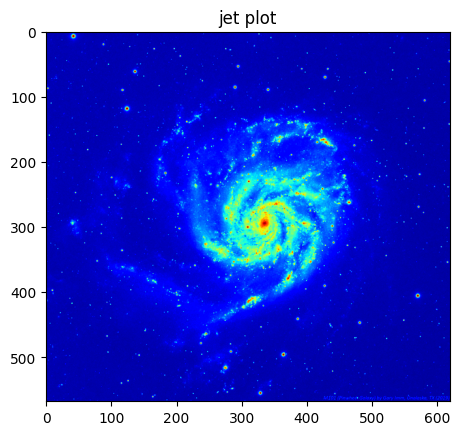

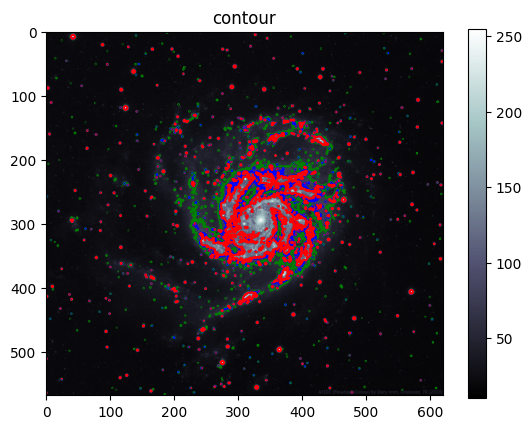

<function matplotlib.pyplot.show(close=None, block=None)>

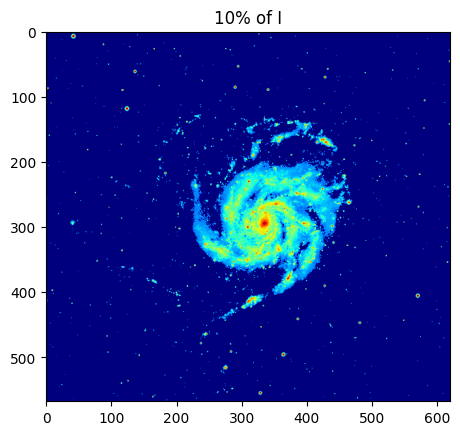

In [40]:
from imageio import imread
from matplotlib import pyplot as plt
import numpy as np

m101 = imread("quiz5_9.jpg")


plt.figure()       #makes a test plot for the figure
plt.imshow(m101, cmap='jet')        #takes the image and puts it in the subplot
plt.title("jet plot")
plt.show()

plt.figure()
plt.imshow(m101, cmap=('bone'))
plt.colorbar()
plt.contour(m101, levels = ([67, 88, 99]), colors =('g','b','r'))
plt.title("contour")
plt.show()

plt.figure()
I = np.percentile(m101, [90])
nameit = np.where(m101 > I, m101,0)
plt.imshow(nameit, cmap='jet')
plt.title("10% of I")
plt.show()

[0.00482 0.00666 0.00705 0.00889 0.01269 0.02012 0.02789 0.03712 0.03985
 0.04617 0.0606  0.04935 0.02734 0.01746 0.0149  0.0247  0.03478 0.03472
 0.03174 0.02931 0.02995 0.02909 0.02687 0.0247  0.02483 0.02504 0.02486
 0.0228  0.01888 0.01625 0.01589 0.01473 0.01294 0.01236 0.01144 0.01118
 0.01038 0.00848 0.00751 0.0072 ]
min = 0.00482
max = 0.0606
sum = 0.89154
mean = 0.0222885
standard deviation = 0.012699434544498428


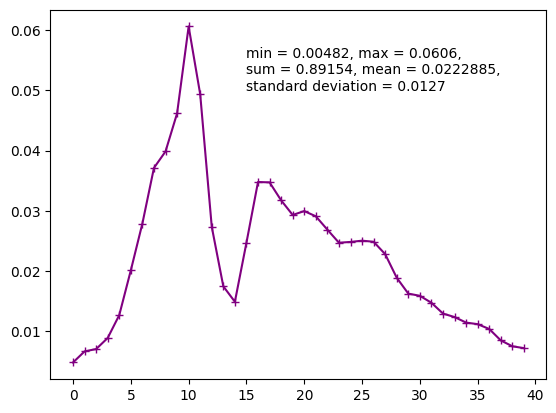

In [13]:
#5.10
import numpy as np
from matplotlib import pyplot as plt

ngc6946 = np.loadtxt("ngc6946")
ngc6946 = ngc6946.reshape(40,50,70)        #reshape it into a 40x50x70 matrix (z,y,x)
middle = ngc6946[:,25,35]        #take all of the z components in the line of x=25,y=35
print(middle)

print(f"min = {np.min(middle)}")
print(f"max = {np.max(middle)}")
print(f"sum = {np.sum(middle)}")
print(f"mean = {np.mean(middle)}")
print(f"standard deviation = {np.std(middle)}")

plt.figure()
plt.plot(middle, marker='+',color='purple')
plt.text(15,0.05,f"min = {np.min(middle)}, max = {np.max(middle)}, \nsum = {np.sum(middle)}, mean = {np.mean(middle)}, \nstandard deviation = {np.std(middle):.3}")
plt.show()

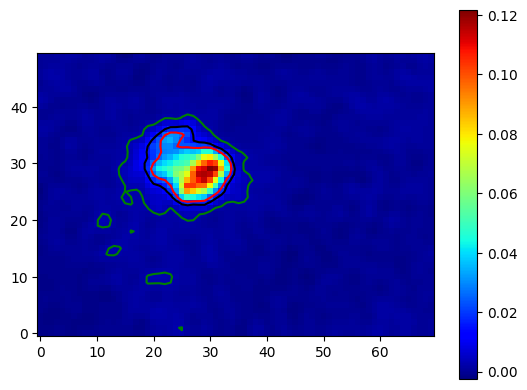

In [41]:
#5.11
import numpy as np
from matplotlib import pyplot as plt

ngc6946 = np.loadtxt("ngc6946")
ngc6946 = ngc6946.reshape(40,50,70)        #reshape it into a 40x50x70 matrix (z,x,y)
plane1 = ngc6946[0,:,:]        #Takes the first plane of the matrix

mean = np.mean(plane1)
std = np.std(plane1)


plt.figure()
plt.imshow(plane1, cmap='jet', origin='lower')       #origin sets the origin in the lower left corner
plt.colorbar()
plt.contour(plane1, levels = ([mean, mean+std, mean+2*std]), colors =('g','black','r'))
plt.show()

In [8]:
#5.12
import scipy.constants

class Galaxy:    
    """Class for redshift calculation of galaxies"""  
        
    caH_0 = 3968.5      # Calcium H line in rest frame
    c = scipy.constants.c/1000      #The speed of light in kilometers
    
    def __init__(self, name, calciumHline=caH_0):
        self.name = name
        self.caH = calciumHline
    def redshift(self):        
        z = (self.caH - self.caH_0)/self.caH        #calculates the redshift
        return z
    def velocity(self):       
        z = self.redshift()
        v = self.c*z        #calculates the speed
        if abs(v)<self.c:       #checks if the speed is not larger than the speed of light
            return v
        else:
            return "This is not a possible calcium line."

line = eval(input("Enter what value for the calcium line you want: "))
a = Galaxy("boop", line)       #takes the class function Galaxy and does the calculations for any aribetrary name (here boop) with the variable of own input of the calcium line.

print(a.velocity())


Enter what value for the calcium line you want:  4000


2360.86560675


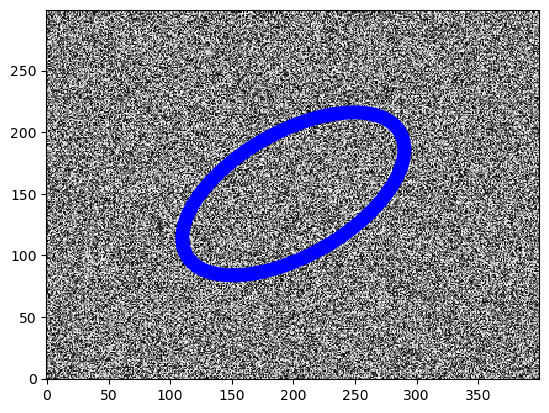

In [15]:
#5.13
import numpy as np
from matplotlib.pyplot import figure, show
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt
Nx = 400
Ny = 300
data = np.random.random((Ny,Nx))        #takes 400 and 300 data points respectively



figure()
ax = plt.gca()       #idk what this does
plt.imshow(data, interpolation='none', origin="lower", cmap='gray')        #maps the data based on a gray scale with origin in the lower left colour
e1 = Ellipse((200, 150), width=200, height=100, angle=30, lw=10, ec='b', fill=False)      #the ellipse centered at 200,150, semi-major axis of 100, semi-miner of 50 with an angle of 30 degrees 
ax.add_patch(e1)       #same with the other
show()